# Introduction

# Data preparation 

We start importing our libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score, 
                             roc_curve,
                             precision_recall_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

Next, we load our dataset and apply .head() and .describe() to familiarize ourselves with them

In [3]:
credit_card = pd.read_csv("datasets/creditcard.csv")

In [4]:
credit_card.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
credit_card[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


Now we are going to look up for duplicates

In [19]:
dups = credit_card.duplicated().sum()

duplicated = dups / len(credit_card) * 100

print(f"There are {dups} duplicates in the dataset")
print(f"The duplicates represent {duplicated:.2f}% of the dataset") 

There are 1081 duplicates in the dataset
The duplicates represent 0.38% of the dataset


Next, we will determine what percentage of our data corresponds to fraud cases

In [25]:
value_counts = credit_card["Class"].value_counts()

percent = value_counts[1] / len(credit_card) * 100

print(f"Fraud transactions represent {percent:.2f}% of the dataset")

Fraud transactions represent 0.17% of the dataset


## Conclusion

No null values or data type inconsistencies were found. However, we found duplicate data (**1,081 duplicates**). Since a large part of the data is in PCA format, we are unable to determine whether these duplicates should be dropped or not. This represents no problem, however, since the duplicated data accounts for only 0.38% of the dataset, so it would not affect our model.

The average transaction amount is **$88.34**, which indicates a typical low-value transaction. The `Time` variable ranges up to **172,792** seconds (*~48 hours*) since the first transaction, which is consistent with the two-day period covered by this dataset.
 
The target variable `Class` takes only two values: **0** (**legitimate transaction**) and **1** (**fraud**), confirming that this is a binary classification problem. Fraud transactions account for 0.17% of the dataset, which suggests a strong class imbalance that will be addressed before modeling.

# EDA (Exploratory Data Analysis)

## Correlation

First, we will calculate the correlation between our target variable `Class` and variables V1 to V26 to determine which of them are most related to fraud transactions.

In [33]:
correlations = credit_card.corr()["Class"].sort_values()

print("Top 5 negative correlations:")
print(correlations.head())
print("\nTop 5 positive correlations:")
print(correlations.tail(6))

Top 5 negative correlations:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Top 5 positive correlations:
V19      0.034783
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64


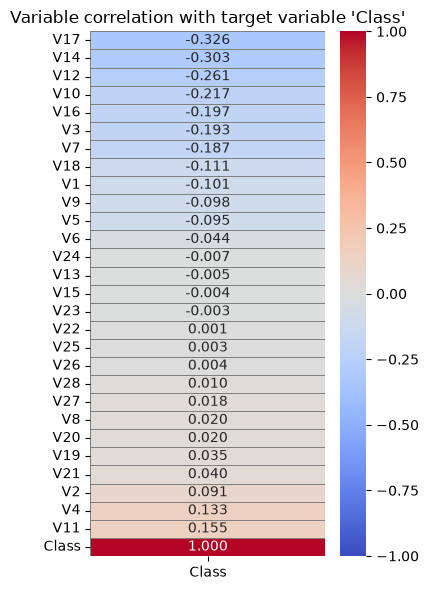

In [46]:
correlations_df = correlations.to_frame()
correlations_df = correlations_df.drop(["Time", "Amount"])

plt.figure(figsize=(4, 6))

sns.heatmap(
    correlations_df,
    annot=True,  
    cmap="coolwarm",  
    fmt=".3f",  
    vmin=-1,
    vmax=1,
    linewidths=.5,
    linecolor="gray")

plt.title("Variable correlation with target variable 'Class'")
plt.tight_layout()
plt.show()

Because of the extreme class imbalance, linear correlations with the target variable appear weak overall — this is expected, since Pearson correlation tends to be diluted when one class dominates the data so heavily. Even so, `V17`, `V14`, `V12`, and `V10` show the strongest negative correlations, while `V11` and `V4` show the strongest positive ones. Given this context, these variables are still likely to be valuable predictors for fraud classification.